# 사전 학습된 모델을 얼리는 방법

In [108]:
import torch
import torch.nn as nn
from torchvision import datasets, models

In [109]:
model = models.resnet34(pretrained=True) # resnet vgg efficientnet

model

c:\Users\user\potenup\python7month\DL\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\potenup\python7month\DL\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [110]:
for param in model.parameters():
    #print(param)
    param.requires_grad = False

In [111]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[[[ 5.4109e-03, -6.9092e-03,  7.8839e-03,  ...,  4.9072e-02,
            3.0660e-02,  2.5398e-02],
          [ 4.1081e-02,  3.1296e-02,  3.2265e-02,  ...,  3.3145e-02,
            2.9754e-02,  4.1735e-02],
          [ 4.9519e-03, -3.1705e-02, -6.1310e-02,  ..., -9.7493e-02,
           -1.1601e-01, -1.2191e-01],
          ...,
          [-1.2287e-02, -2.4841e-02, -9.3052e-03,  ...,  1.7113e-02,
            2.4631e-03,  1.6726e-02],
          [ 3.9117e-03,  4.4537e-03,  3.6315e-02,  ...,  1.0371e-01,
            7.3973e-02,  5.9085e-02],
          [ 1.6784e-02,  8.8902e-03,  3.1312e-02,  ...,  9.6964e-02,
            8.3749e-02,  9.6970e-02]],

         [[-7.7192e-03, -8.7711e-03,  1.4143e-02,  ...,  3.3901e-02,
            2.5483e-02,  2.4275e-02],
          [ 5.3961e-02,  4.4677e-02,  3.4326e-02,  ...,  1.3392e-02,
            1.9135e-02,  3.7995e-02],
          [ 1.0251e-03, -5.4513e-02, -1.0225e-01,  ..., -1.9231e-01,
           -1.9994e-01, -1.8192e-01]

In [112]:
model.fc = nn.Linear(in_features=512, out_features=2)

In [113]:
#layer1의 파라미터들을 얼려라!
for param in model.layer1.parameters():
    param.requires_grad = False

# 사람얼굴 분류 모델 (사전학습), 데이터 직접 가져오기 

In [114]:
# !git clone https://github.com/ndb796/bing_image_downloader

In [115]:
import os
import shutil

directory_list = [
    'C:/Users/user/potenup/data_resources/dataset/train/',
    'C:/Users/user/potenup/data_resources/dataset/test/'
]

# for dir in directory_list:
#     os.makedirs(dir) # 경로에 폴더 만들어라

### 연예인 이미지 다운로드

In [116]:
from bing_image_downloader.bing_image_downloader import downloader
# downloader.download(query="마동석", limit=50, output_dir='./', adult_filter_off=True, force_replace=False, timeout=60)
# downloader.download(query="카리나", limit=50, output_dir='./', adult_filter_off=True, force_replace=False, timeout=60)
# downloader.download(query="노홍철", limit=50, output_dir='./', adult_filter_off=True, force_replace=False, timeout=60)

In [117]:
query_list = ['노홍철', "마동석", '카리나']

def dataset_split(query, train_cnt): #카리나, 30
    for dir in directory_list: #dir - C:/Users/user/potenup/data_resources/dataset/train/ or /test/
        if not os.path.isdir(dir + query): #쿼리명으로 된 폴더가 없으면 새로 만들어라
            os.makedirs(dir + query)  
        
    cnt = 0

    for file_name in os.listdir(query):
        if cnt < train_cnt:
            shutil.move(query+"/"+file_name, 'C:/Users/user/potenup/data_resources/dataset/train/' + query + '/' + file_name)
        else:
            shutil.move(query+"/"+file_name, 'C:/Users/user/potenup/data_resources/dataset/test/' + query + '/' + file_name)

        cnt += 1

    shutil.rmtree(query)

In [118]:
# dataset_split('노홍철', 40)
# dataset_split('마동석', 40)
# dataset_split('이수지', 40)

In [119]:
# dataset_split('마동석', 40)

In [120]:
# dataset_split('카리나', 40)

In [121]:
# os.listdir('카리나')

In [122]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time

In [123]:
transforms_train = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #RGB 의 mean, std
    ]
)
transforms_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #RGB 의 mean, std
    ]
)

## 이미지를 정답데이터별로 labeling 해서 가져와줌
train_datasets = datasets.ImageFolder(root="../../data_resources/dataset/train", transform=transforms_train)
test_datasets = datasets.ImageFolder(root="../../data_resources/dataset/test", transform=transforms_test)

In [124]:
train_datasets.classes
test_datasets.classes

['노홍철', '마동석', '카리나']

In [125]:
test_datasets

Dataset ImageFolder
    Number of datapoints: 30
    Root location: ../../data_resources/dataset/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [126]:
train_datasets

Dataset ImageFolder
    Number of datapoints: 120
    Root location: ../../data_resources/dataset/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [127]:
train_dataloader = torch.utils.data.DataLoader(train_datasets, batch_size=4, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_datasets, batch_size=4, shuffle=False)

In [128]:
next(iter(train_dataloader))

[tensor([[[[ 1.3070,  1.3070,  1.3070,  ...,  1.3413,  1.3242,  1.3070],
           [ 1.3242,  1.3070,  1.3242,  ...,  1.3070,  1.3070,  1.2899],
           [ 1.3242,  1.3070,  1.3242,  ...,  1.3070,  1.2899,  1.2899],
           ...,
           [ 1.1872,  1.1872,  1.1872,  ...,  1.1872,  1.1872,  1.1872],
           [ 1.1700,  1.1700,  1.1700,  ...,  1.2043,  1.2043,  1.2043],
           [ 0.3823,  0.3994,  0.3994,  ...,  1.2214,  1.2043,  1.2043]],
 
          [[ 1.5007,  1.5007,  1.5007,  ...,  1.5357,  1.5182,  1.5182],
           [ 1.5182,  1.5007,  1.5182,  ...,  1.5357,  1.5357,  1.5182],
           [ 1.5182,  1.5007,  1.5182,  ...,  1.5182,  1.5182,  1.5182],
           ...,
           [ 1.3606,  1.3782,  1.3606,  ...,  1.3782,  1.3957,  1.3957],
           [ 1.3431,  1.3431,  1.3431,  ...,  1.3957,  1.3957,  1.4132],
           [ 0.2052,  0.2227,  0.2402,  ...,  1.4132,  1.3957,  1.3957]],
 
          [[ 1.6988,  1.6988,  1.6988,  ...,  1.7337,  1.7511,  1.7511],
           [ 

In [129]:
import numpy as np
import matplotlib.pyplot as plt

In [130]:
def imshow(img, title):
    img_data = img.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_data = std * img_data + mean
    img_data = np.clip(img_data, 0, 1)

    plt.imshow(img_data)
    plt.title(title)
    plt.axis("off")
    plt.show()

### 배치 단위로 묶어서 출력

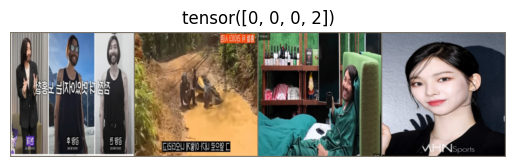

In [ ]:
images, labels = next(iter(train_dataloader))

images_data = torchvision.utils.make_grid(images)

imshow(images_data, labels)

In [132]:
model = models.resnet34(pretrained=True)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [133]:
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(in_features=512, out_features=3, bias=True)


In [134]:
from tensorboardX import SummaryWriter
from tqdm import tqdm
writer = SummaryWriter()

lr = 1e-3
optim = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
epochs = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'
step = 0

model.to(device)

for epoch in range(epochs):
    for images, labels in tqdm(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)

        optim.zero_grad()

        pred = model(images)
        loss = criterion(pred, labels)

        loss.backward()
        optim.step()

        writer.add_scalar('Loss/train', loss.item(), step)
        step += 1

    print(f"{epoch} epoch loss: {loss.item()}")

100%|██████████| 30/30 [00:04<00:00,  6.34it/s]


0 epoch loss: 0.9426504373550415


100%|██████████| 30/30 [00:04<00:00,  6.97it/s]


1 epoch loss: 1.1281163692474365


100%|██████████| 30/30 [00:04<00:00,  6.75it/s]


...

47 epoch loss: 0.216817706823349


100%|██████████| 30/30 [00:03<00:00,  7.83it/s]


48 epoch loss: 0.0074935974553227425


100%|██████████| 30/30 [00:04<00:00,  7.12it/s]

49 epoch loss: 0.009960204362869263


In [135]:
# with torch.no_grad(): # gradient 계산 비활성화
#     for images, labels in test_loader:
#         images = images.to(device)  # (B, 1, 32, 32) 이어야 함
#         labels = labels.to(device)

#         logits = model(images)
#         pred = logits.argmax(dim=1)
#         correct += (pred == labels).sum().item()
#         total += label.size(0)

예측결과: tensor([0, 0, 0, 0], device='cuda:0'), 정답:tensor([0, 0, 0, 0])


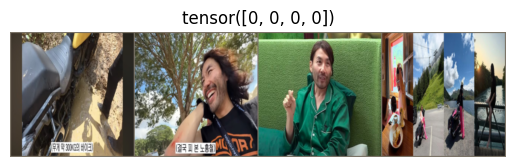

예측결과: tensor([0, 0, 0, 0], device='cuda:0'), 정답:tensor([0, 0, 0, 0])


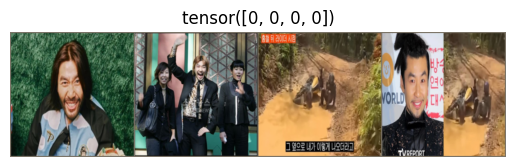

예측결과: tensor([0, 0, 1, 1], device='cuda:0'), 정답:tensor([0, 0, 1, 1])


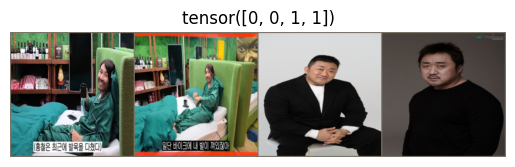

예측결과: tensor([1, 1, 1, 1], device='cuda:0'), 정답:tensor([1, 1, 1, 1])


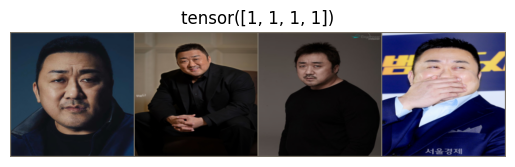

예측결과: tensor([1, 1, 1, 1], device='cuda:0'), 정답:tensor([1, 1, 1, 1])


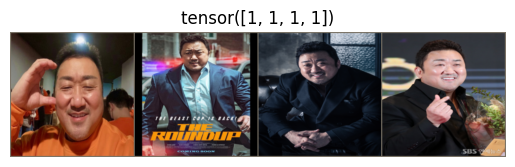

예측결과: tensor([2, 2, 2, 2], device='cuda:0'), 정답:tensor([2, 2, 2, 2])


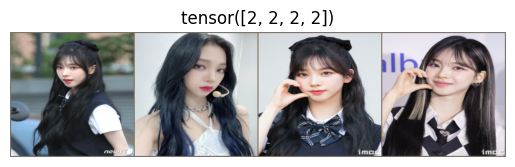

예측결과: tensor([2, 2, 2, 2], device='cuda:0'), 정답:tensor([2, 2, 2, 2])


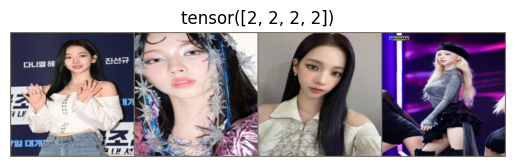

예측결과: tensor([2, 2], device='cuda:0'), 정답:tensor([2, 2])


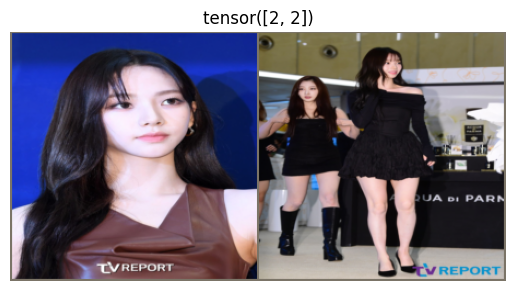

최종 정확도:  tensor(1., device='cuda:0')


In [136]:
model.eval()
correct = 0
total = 0
total_pred = 0

with torch.no_grad():
    for images, label in test_dataloader:

        logits = model(images.to(device))
        pred = torch.max(logits, 1)[1]

        total_pred += torch.sum(pred == label.to(device).data)
        print(f"예측결과: {pred}, 정답:{label}")
        images_data = torchvision.utils.make_grid(images)
        imshow(images_data.to('cpu'), label)

print("최종 정확도: ", total_pred / len(test_datasets))
        
        # pred = logits.argmax(dim = 1)
        # correct += (pred == label.to(device)).sum().item()
        # total += label.size(0)


In [137]:
from PIL import Image

image = Image.open('../../data_resources/dataset/test/카리나/image_5.jpg')
image = transforms_test(image).unsqueeze(0).to(device)

result = model(image)
torch.max(result, 1)[1]



tensor([2], device='cuda:0')

## 모델 저장

In [138]:
torch.save(model.state_dict(), 'mymodel.pth') #가중치만 저장

In [139]:
torch.save(model, 'my_mode1.pth') #모델 정보 전체를 한번에 저장